In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None, names=column_names, na_values='?')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("Unique values in target column:")
print(df['target'].unique())

print("\nTarget value counts:")
print(df['target'].value_counts().sort_index())

feature_explanation = {
    'age': 'Age of the patient in years',
    'sex': 'Sex (1 = male, 0 = female)',
    'cp': 'Chest pain type (1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)',
    'restecg': 'Resting electrocardiographic results (0 = normal, 1 = ST-T abnormality, 2 = left ventricular hypertrophy)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (1 = yes, 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'Slope of peak exercise ST segment (1 = upsloping, 2 = flat, 3 = downsloping)',
    'ca': 'Number of major vessels (0-3) colored by fluoroscopy',
    'thal': 'Thalassemia test result (3 = normal, 6 = fixed defect, 7 = reversible defect)',
    'target': 'Diagnosis of heart disease (0 = no disease, 1-4 = presence of disease)'
}

for col, meaning in feature_explanation.items():
    print(f"{col}: {meaning}")

Shape of dataset: (303, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  target
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3    3.0  0.0   6.0       0
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5    2.0  3.0   3.0       2
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6    2.0  2.0   7.0       1
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5    3.0  0.0   3.0       0
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4    1.0  0.0   3.0       0

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope 

In [4]:
# =========================
# STEP 3A: HANDLE MISSING VALUES
# =========================

print("Missing values before imputation:")
print(df.isnull().sum())

# Fill missing values using mode
df['ca'].fillna(df['ca'].mode()[0], inplace=True)
df['thal'].fillna(df['thal'].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())

# =========================
# STEP 3B: CHECK DUPLICATES
# =========================

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)

# =========================
# STEP 3C: CONVERT TARGET TO BINARY
# =========================

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(df['target'].value_counts())

numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal'
]
print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Missing values before imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Number of duplicate rows: 0
target
0    164
1    139
Name: count, dtype: int64
Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


/tmp/ipykernel_2088/1825719417.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ca'].fillna(df['ca'].mode()[0], inplace=True)
/tmp/ipykernel_2088/1825719417.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

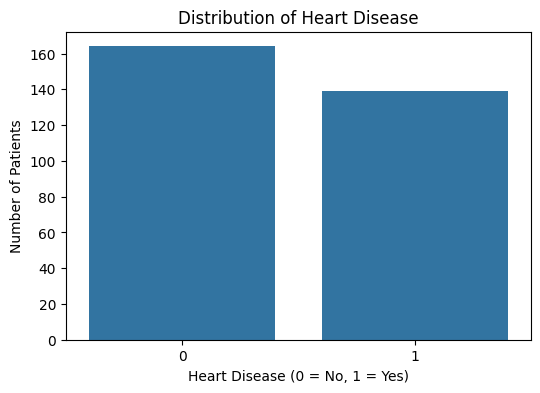

target
0    164
1    139
Name: count, dtype: int64


In [5]:
# =========================
# EDA 1: TARGET DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

print(df['target'].value_counts())

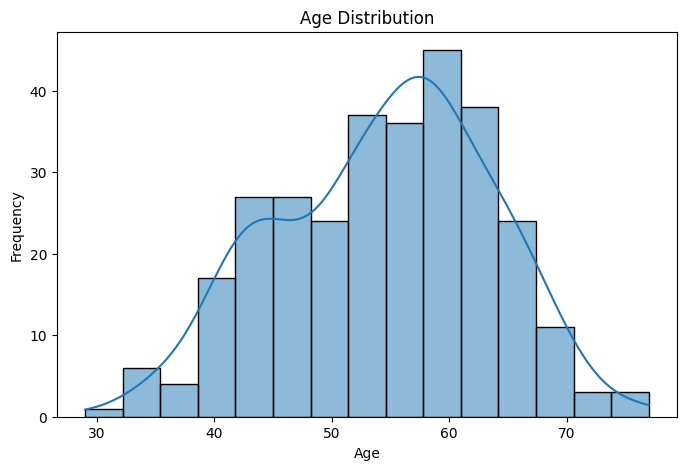

In [6]:
# =========================
# EDA 2: AGE DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

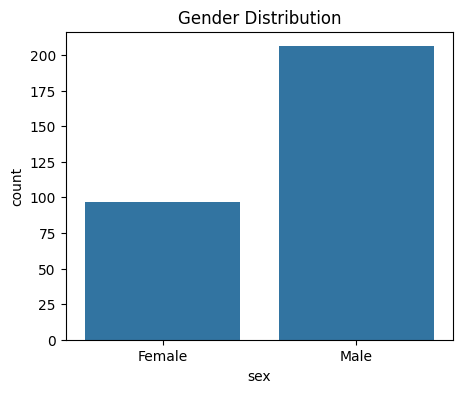

sex
1.0    206
0.0     97
Name: count, dtype: int64


In [7]:
# =========================
# EDA 3: GENDER DISTRIBUTION
# =========================

plt.figure(figsize=(5,4))

sns.countplot(x='sex', data=df)

plt.xticks([0,1], ['Female','Male'])

plt.title("Gender Distribution")

plt.show()

print(df['sex'].value_counts())

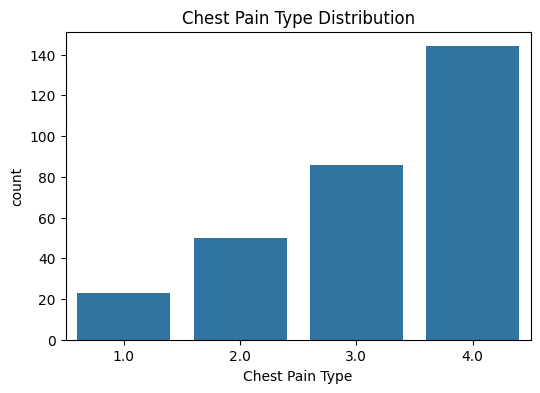

In [8]:
# =========================
# EDA 4: CHEST PAIN TYPES
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x='cp', data=df)

plt.title("Chest Pain Type Distribution")

plt.xlabel("Chest Pain Type")

plt.show()

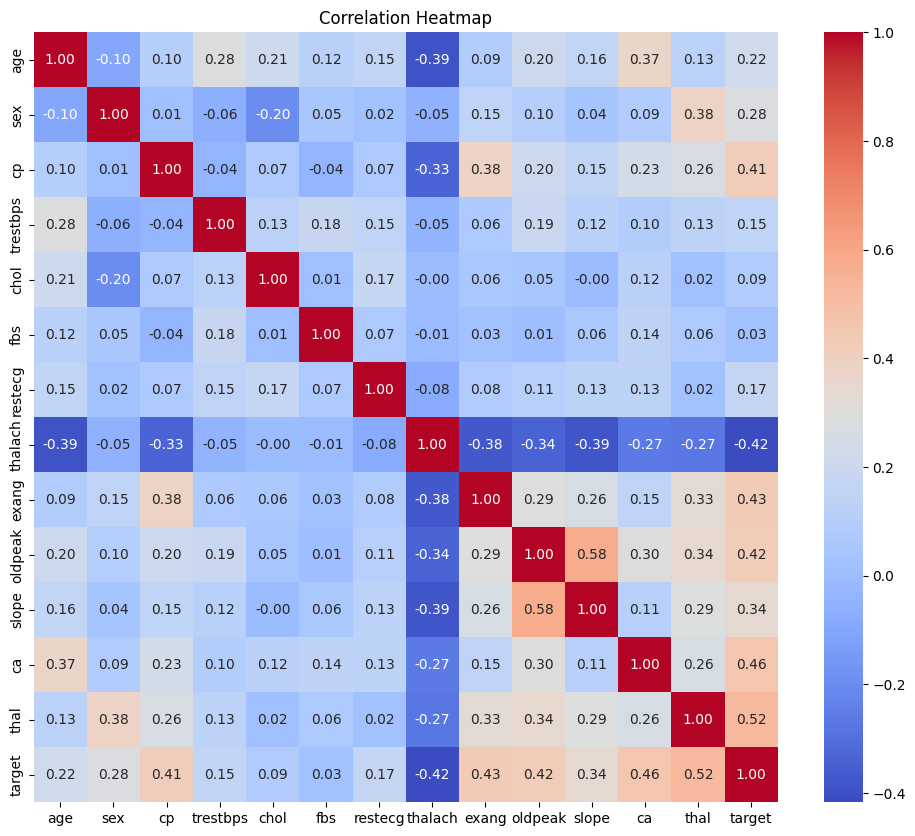

In [9]:
# =========================
# EDA 5: CORRELATION HEATMAP
# =========================

plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

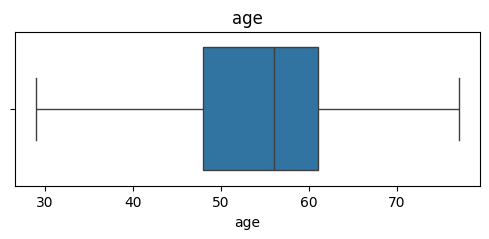

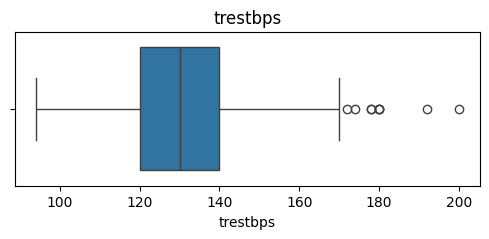

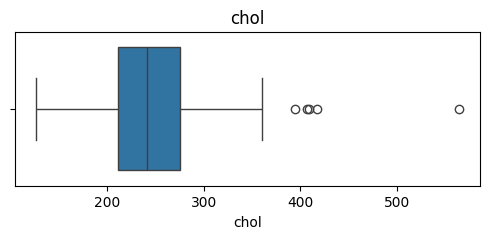

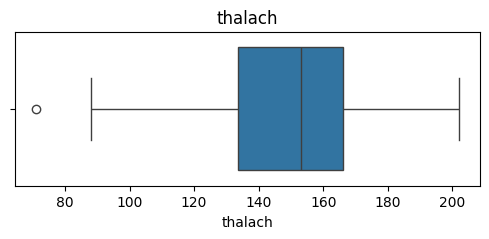

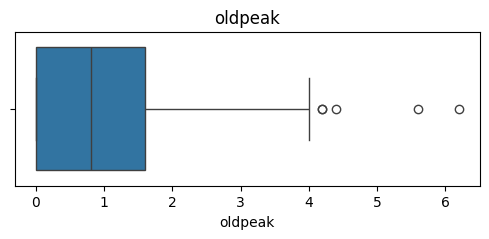

In [10]:
# =========================
# EDA 6: BOXPLOTS
# =========================

numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

for feature in numerical_features:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[feature])

    plt.title(feature)

    plt.show()

In [11]:
# =========================
# STEP 5A: IMPORT ML LIBRARIES
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# STEP 5B: FEATURES & TARGET
# =========================

X = df.drop('target', axis=1)
y = df['target']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# =========================
# STEP 5C: TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# =========================
# STEP 5D: FEATURE SCALING
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Shape of X: (303, 13)
Shape of y: (303,)
Training samples: 242
Testing samples: 61


In [12]:
# =========================
# STEP 5F: MODEL EVALUATION
# =========================

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("="*50)
    print(model_name)
    print("="*50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [13]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results
])

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

Logistic Regression
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 Score : 0.8667

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Confusion Matrix:
[[27  6]
 [ 2 26]]
Decision Tree
Accuracy : 0.7377
Precision: 0.6765
Recall   : 0.8214
F1 Score : 0.7419

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.67      0.73        33
           1       0.68      0.82      0.74        28

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.75      0.74      0.74        61


Confusion Matrix:
[[22 11]
 [ 5 23]]
Random Forest
Accuracy : 0.8852
Precision:

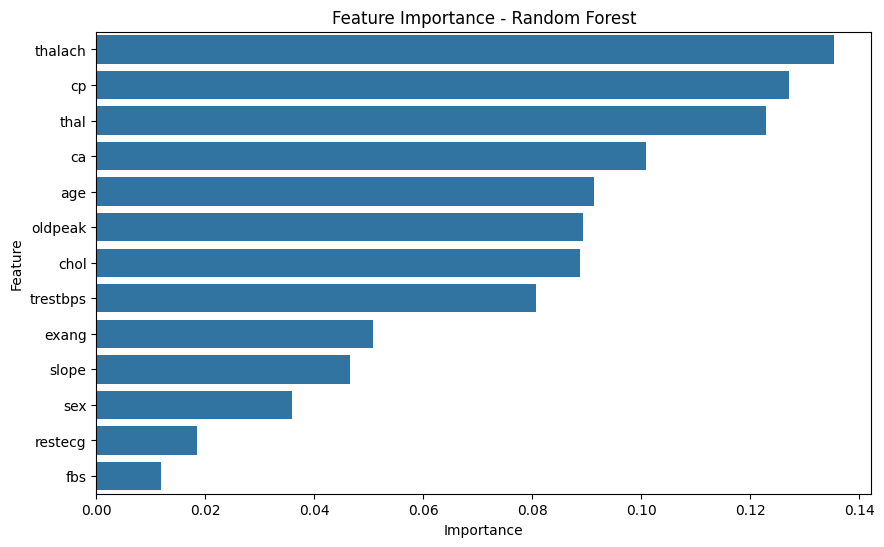

     Feature  Importance
7    thalach    0.135404
2         cp    0.127163
12      thal    0.122940
11        ca    0.100811
0        age    0.091327
9    oldpeak    0.089358
4       chol    0.088681
3   trestbps    0.080716
8      exang    0.050730
10     slope    0.046626
1        sex    0.035947
6    restecg    0.018389
5        fbs    0.011908


In [14]:
# =========================
# FEATURE IMPORTANCE
# =========================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Random Forest")

plt.show()

print(feature_importance)

In [15]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(lr, "model/logistic_regression.pkl")
joblib.dump(dt, "model/decision_tree.pkl")
joblib.dump(rf, "model/random_forest.pkl")

print("Models saved successfully!")

Models saved successfully!


In [17]:
import os

os.makedirs("results", exist_ok=True)

results.to_csv("results/model_comparison.csv", index=False)

feature_importance.to_csv(
    "results/feature_importance.csv",
    index=False
)